In [1]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# !pip install pandas
# !pip install scikit-learn
# !pip install matplotlib

TASK 2A

In [13]:
import pandas as pd
import torch 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [14]:
df = pd.read_csv('DL_Dataset.csv')

In [15]:
df.head()

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-03-21,0.134050,2.725836,4.027056,3.989428,1.973108,0.0,4.067350,3.432983,...,4.268562,0.000000,3.179261,0.000000,1.0,0.2,0.2,6.20,153.665872,0.0
1,AS14.01,2014-03-22,0.236880,2.172608,3.964560,3.864134,2.082603,0.0,0.000000,2.709411,...,3.645580,0.000000,3.694041,0.000000,1.0,0.6,0.5,6.40,47.613651,1.0
2,AS14.01,2014-03-23,0.142741,2.575234,3.997136,3.479659,2.472391,0.0,0.000000,2.575445,...,0.000000,0.000000,3.436758,3.446362,0.0,0.2,0.8,6.80,67.067644,0.0
3,AS14.01,2014-03-24,0.078961,1.788840,3.882423,4.813171,1.899766,0.0,1.388791,2.492627,...,4.442192,0.000000,4.503868,0.000000,1.0,0.8,0.0,6.00,76.772199,0.0
4,AS14.01,2014-03-25,0.098374,2.400335,4.254726,3.558287,2.465002,0.0,0.000000,3.427617,...,0.000000,3.414537,3.147994,0.000000,0.0,0.5,0.5,6.75,169.097283,1.0


In [16]:
# The mood column will now be binned after the train-test split.
# This cell is now just for inspecting the dataframe.
df.head(20)

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-03-21,0.134050,2.725836,4.027056,3.989428,1.973108,0.000000,4.067350,3.432983,...,4.268562,0.000000,3.179261,0.000000,1.0,0.200000,0.200000,6.20,153.665872,0.0
1,AS14.01,2014-03-22,0.236880,2.172608,3.964560,3.864134,2.082603,0.000000,0.000000,2.709411,...,3.645580,0.000000,3.694041,0.000000,1.0,0.600000,0.500000,6.40,47.613651,1.0
2,AS14.01,2014-03-23,0.142741,2.575234,3.997136,3.479659,2.472391,0.000000,0.000000,2.575445,...,0.000000,0.000000,3.436758,3.446362,0.0,0.200000,0.800000,6.80,67.067644,0.0
3,AS14.01,2014-03-24,0.078961,1.788840,3.882423,4.813171,1.899766,0.000000,1.388791,2.492627,...,4.442192,0.000000,4.503868,0.000000,1.0,0.800000,0.000000,6.00,76.772199,0.0
4,AS14.01,2014-03-25,0.098374,2.400335,4.254726,3.558287,2.465002,0.000000,0.000000,3.427617,...,0.000000,3.414537,3.147994,0.000000,0.0,0.500000,0.500000,6.75,169.097283,1.0
5,AS14.01,2014-03-26,0.101308,2.247085,3.872482,4.875720,2.274374,0.000000,0.000000,2.847793,...,0.000000,0.000000,3.537039,0.000000,0.0,-0.200000,0.600000,6.60,94.389661,0.0
6,AS14.01,2014-03-27,0.159511,2.195294,3.792185,4.277189,2.712905,0.000000,2.785274,2.375402,...,3.205061,0.000000,2.849281,0.000000,1.0,0.200000,0.800000,7.00,129.201111,1.0
7,AS14.01,2014-03-28,0.095698,4.408546,3.222019,4.526130,2.620166,4.766592,0.000000,3.654767,...,4.104824,0.000000,3.439511,0.000000,1.0,-0.600000,0.600000,6.40,55.948739,0.0
8,AS14.01,2014-03-29,0.068203,3.199720,3.886324,4.695881,0.000000,0.000000,0.000000,3.227943,...,2.916599,0.000000,3.259117,0.000000,1.0,0.200000,1.000000,8.00,130.040969,1.0
9,AS14.01,2014-03-30,0.049093,2.176819,4.140490,5.145346,0.000000,0.000000,0.000000,2.590305,...,0.000000,3.533351,3.671123,0.000000,0.0,-0.500000,0.750000,7.50,167.526444,0.0


In [17]:
def plot_class_distribution(data, title):
    """
    Calculates and displays the class distribution for a given pandas Series or NumPy array
    and plots a bar graph.
    """
    if isinstance(data, pd.Series):
        counts = data.value_counts().sort_index()
        class_labels = counts.index
    elif isinstance(data, np.ndarray):
        class_labels, counts = np.unique(data, return_counts=True)
    else:
        print(f"Unsupported data type: {type(data)}")
        return

    # Calculate class distribution
    split_df = pd.DataFrame({
        'count': counts,
        'percent': (counts / counts.sum() * 100).round(2)
    }, index=class_labels)
    split_df.index.name = 'class'
    
    # Display the distribution table
    print(f"{title} class distribution")
    print(f"Total samples: {int(counts.sum())}")
    display(split_df)
    
    plt.figure(figsize=(8, 4))
    plt.bar(split_df.index.astype(str), split_df['count'])
    plt.xlabel('Mood Value (Class)')
    plt.ylabel('Count')
    plt.title(f'{title} Mood Value Distribution')
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler

WINDOW = 5
ID_COL = "id"
DATE_COL = "date"
TARGET_COL = "mood"

TRAIN_SPLIT= 0.8
VAL_SPLIT = .1

df = df.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in [ID_COL, DATE_COL, TARGET_COL]]

X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
skipped_gap_windows = 0

# create samples without crossing date gaps
for _, g in df.groupby(ID_COL, sort=False):
    g = g.sort_values(DATE_COL).reset_index(drop=True)
    n = len(g)
    if n <= WINDOW:
        continue

    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)
    train_end = n_train
    val_end = n_train + n_val

    x = g[feature_cols].to_numpy(dtype=np.float32)
    y = g[TARGET_COL]

    for t in range(WINDOW - 1, n - 1):
        seq = x[t - WINDOW + 1:t + 1]
        label = y[t + 1]

        if t + 1 < train_end:
            X_train.append(seq)
            y_train.append(label)
        elif t + 1 < val_end:
            X_val.append(seq)
            y_val.append(label)
        else:
            X_test.append(seq)
            y_test.append(label)

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Standardize features using training data
scaler = StandardScaler()
num_features = X_train.shape[2]
X_train = scaler.fit_transform(X_train.reshape(-1, num_features)).reshape(X_train.shape).astype(np.float32)
X_val = scaler.transform(X_val.reshape(-1, num_features)).reshape(X_val.shape).astype(np.float32)
X_test = scaler.transform(X_test.reshape(-1, num_features)).reshape(X_test.shape).astype(np.float32)
print("Standardization: applied (fit on train only)")

print("feature count:", len(feature_cols))
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Standardization: applied (fit on train only)
feature count: 18
X_train: (823, 5, 18) y_train: (823,)
X_val  : (109, 5, 18) y_val  : (109,)
X_test : (147, 5, 18) y_test : (147,)


In [19]:
y_train

array([6.6      , 7.       , 6.4      , 8.       , 7.5      , 7.4      ,
       6.       , 6.5      , 6.4      , 6.2      , 6.8      , 6.5      ,
       6.5      , 6.6      , 7.4      , 7.4      , 7.       , 7.25     ,
       8.       , 7.2      , 6.4      , 7.2      , 6.6      , 6.8      ,
       7.8      , 7.25     , 7.6      , 7.4      , 7.6      , 7.6      ,
       7.2      , 7.5      , 6.5      , 6.25     , 6.4      , 7.75     ,
       7.2      , 7.25     , 6.8      , 7.25     , 7.       , 7.2      ,
       7.4      , 6.4      , 5.75     , 6.4      , 7.4      , 4.5      ,
       6.8      , 6.25     , 7.25     , 7.25     , 6.5      , 6.       ,
       7.2      , 8.       , 7.25     , 8.25     , 7.75     , 8.       ,
       8.6      , 8.4      , 7.4      , 7.6      , 7.4      , 7.8      ,
       7.8      , 7.6      , 6.8      , 7.4      , 7.4      , 7.8      ,
       7.4      , 7.6      , 7.6666665, 7.4      , 7.       , 7.6      ,
       8.       , 7.25     , 7.5      , 7.8      , 

Original Mood Distribution (Before Binning) class distribution
Total samples: 1214


,count,percent
class,,
3.000000,1,0.08
3.333333,1,0.08
3.500000,2,0.16
3.750000,2,0.16
3.800000,1,0.08
...,...,...
8.666667,1,0.08
8.750000,1,0.08
8.800000,2,0.16


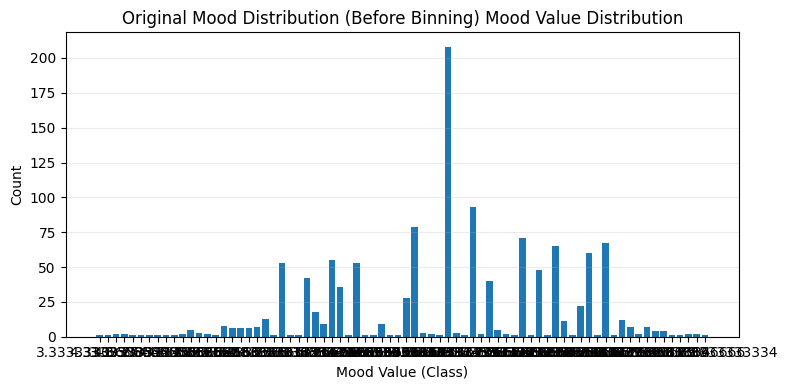

Lower threshold (33rd percentile): 6.8000
Upper threshold (66th percentile): 7.2500

Class counts (training):
0    313
1    246
2    264
Name: count, dtype: int64

Class counts (validation):
0    39
1    33
2    37
Name: count, dtype: int64

Class counts (test):
0    54
1    43
2    50
Name: count, dtype: int64

Shapes after class mapping:
y_train: (823,)
y_val  : (109,)
y_test : (147,)


In [35]:
# Plot original mood distribution before binning
plot_class_distribution(df['mood'], "Original Mood Distribution (Before Binning)")

# Compute thresholds from training targets only (prevents leakage)
mood_values = pd.Series(y_train)
q33 = mood_values.quantile(0.33)
q66 = mood_values.quantile(0.66)

print(f"Lower threshold (33rd percentile): {q33:.4f}")
print(f"Upper threshold (66th percentile): {q66:.4f}")

def mood_to_class(mood):
    if mood <= q33:
        return 0  # Low
    elif mood <= q66:
        return 1  # Medium
    return 2  # High

# Apply the same mapping to all splits
y_train = np.array(pd.Series(y_train).apply(mood_to_class), dtype=np.int64)
y_val = np.array(pd.Series(y_val).apply(mood_to_class), dtype=np.int64)
y_test = np.array(pd.Series(y_test).apply(mood_to_class), dtype=np.int64)

# Keep edges for report labels in later cells
bins = [-np.inf, q33, q66, np.inf]

print("\nClass counts (training):")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass counts (validation):")
print(pd.Series(y_val).value_counts().sort_index())

print("\nClass counts (test):")
print(pd.Series(y_test).value_counts().sort_index())

print("\nShapes after class mapping:")
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

Training Set class distribution
Total samples: 823


,count,percent
class,,
0,313,38.03
1,246,29.89
2,264,32.08


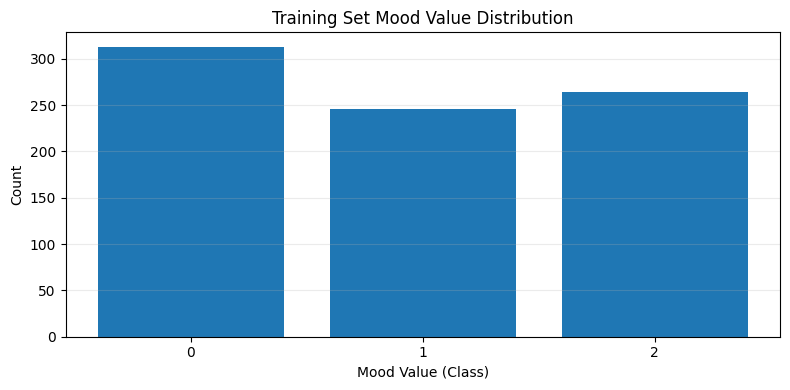

Validation Set class distribution
Total samples: 109


,count,percent
class,,
0,39,35.78
1,33,30.28
2,37,33.94


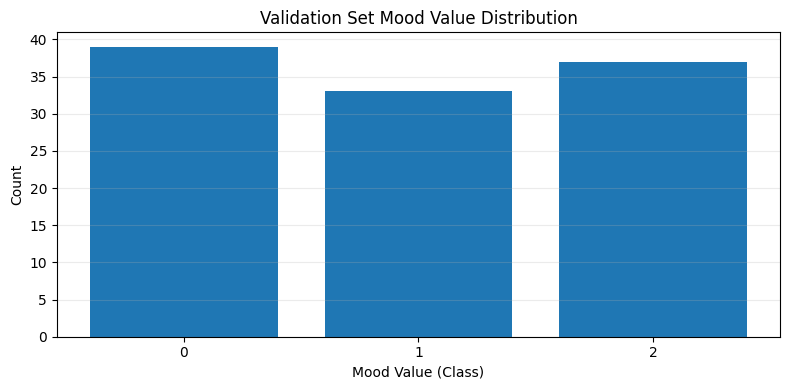

Test Set class distribution
Total samples: 147


,count,percent
class,,
0,54,36.73
1,43,29.25
2,50,34.01


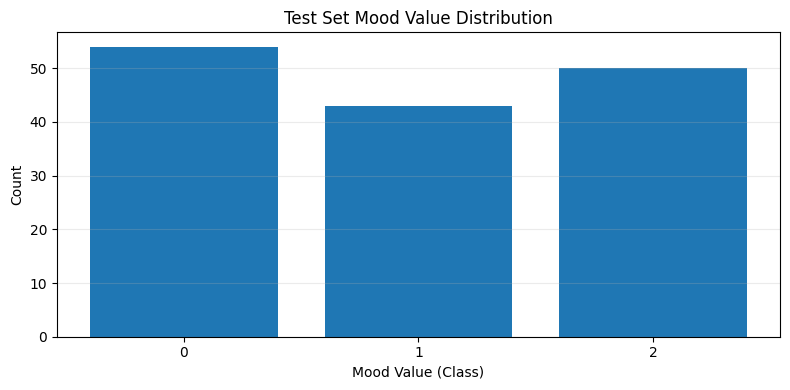

In [36]:
plot_class_distribution(y_train, "Training Set")
plot_class_distribution(y_val, "Validation Set")
plot_class_distribution(y_test, "Test Set")

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


In [44]:
# No class weights: use unweighted loss everywhere.
print("Class weights disabled. Using unweighted CrossEntropyLoss.")

Class weights disabled. Using unweighted CrossEntropyLoss.


Functions to train and evaluate


In [45]:
import time
from sklearn.model_selection import ParameterGrid, StratifiedKFold

def predict_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            trues.extend(yb.numpy().tolist())
    return np.array(trues), np.array(preds)

def evaluate_model(model, loader):
    y_true, y_pred = predict_model(model, loader)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return acc, macro_f1, y_true, y_pred

def train_simple_model(
    model,
    train_loader,
    val_loader,
    criterion,
    lr=1e-3,
    epochs=40,
    patience=8,
    model_name="Model",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0
    train_losses, val_losses = [], []

    train_count = max(len(train_loader.dataset), 1)
    val_count = max(len(val_loader.dataset), 1)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)

        train_loss /= train_count
        val_loss /= val_count
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"{model_name} | Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"{model_name} | Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    epochs_ran = len(train_losses)
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs_ran + 1), train_losses, marker="o", label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), val_losses, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name}: Training Curves")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    history = {
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_ran": epochs_ran,
    }
    return model, history

def train_fold_for_cv(
    model,
    train_loader,
    val_loader,
    criterion,
    lr,
    epochs=20,
    patience=5,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_f1 = -1.0
    best_state = None
    wait = 0

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        _, val_f1, _, _ = evaluate_model(model, val_loader)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return best_val_f1

def grid_search_cv_cnnlstm(
    param_grid,
    X,
    y,
    n_splits=3,
    batch_size=64,
    cv_epochs=20,
    cv_patience=5,
    random_state=42,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for params in ParameterGrid(param_grid):
        fold_f1s = []
        fold_times = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            x_tr = torch.tensor(X[train_idx], dtype=torch.float32)
            y_tr = torch.tensor(y[train_idx], dtype=torch.long)
            x_va = torch.tensor(X[val_idx], dtype=torch.float32)
            y_va = torch.tensor(y[val_idx], dtype=torch.long)

            tr_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=batch_size, shuffle=True)
            va_loader = DataLoader(TensorDataset(x_va, y_va), batch_size=256, shuffle=False)

            criterion = nn.CrossEntropyLoss()

            model = CNNLSTMClassifier(
                input_size=X.shape[2],
                conv_channels=params["conv_channels"],
                conv_layers=params["conv_layers"],
                kernel_size=params["kernel_size"],
                lstm_hidden=params["lstm_hidden"],
                lstm_layers=params["lstm_layers"],
                dropout=params["dropout"],
                n_classes=3,
            ).to(device)

            start = time.time()
            best_fold_f1 = train_fold_for_cv(
                model=model,
                train_loader=tr_loader,
                val_loader=va_loader,
                criterion=criterion,
                lr=params["lr"],
                epochs=cv_epochs,
                patience=cv_patience,
            )
            elapsed = time.time() - start

            fold_f1s.append(best_fold_f1)
            fold_times.append(elapsed)
            print(
                f"params={params} | fold={fold_idx}/{n_splits} | "
                f"best_val_macro_f1={best_fold_f1:.4f} | time={elapsed:.1f}s"
            )

        row = {
            **params,
            "cv_macro_f1_mean": float(np.mean(fold_f1s)),
            "cv_macro_f1_std": float(np.std(fold_f1s)),
            "cv_time_sec_mean": float(np.mean(fold_times)),
        }
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(
        ["cv_macro_f1_mean", "cv_macro_f1_std"],
        ascending=[False, True],
    ).reset_index(drop=True)

    best_params = results_df.iloc[0].to_dict() if not results_df.empty else None
    return best_params, results_df

def grid_search_cv_lstm(
    param_grid,
    X,
    y,
    n_splits=3,
    batch_size=64,
    cv_epochs=20,
    cv_patience=5,
    random_state=42,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for params in ParameterGrid(param_grid):
        fold_f1s = []
        fold_times = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            x_tr = torch.tensor(X[train_idx], dtype=torch.float32)
            y_tr = torch.tensor(y[train_idx], dtype=torch.long)
            x_va = torch.tensor(X[val_idx], dtype=torch.float32)
            y_va = torch.tensor(y[val_idx], dtype=torch.long)

            tr_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=batch_size, shuffle=True)
            va_loader = DataLoader(TensorDataset(x_va, y_va), batch_size=256, shuffle=False)

            criterion = nn.CrossEntropyLoss()

            model = LSTMClassifier(
                input_size=X.shape[2],
                lstm_hidden=params["lstm_hidden"],
                lstm_layers=params["lstm_layers"],
                dropout=params["dropout"],
                n_classes=3,
            ).to(device)

            start = time.time()
            best_fold_f1 = train_fold_for_cv(
                model=model,
                train_loader=tr_loader,
                val_loader=va_loader,
                criterion=criterion,
                lr=params["lr"],
                epochs=cv_epochs,
                patience=cv_patience,
            )
            elapsed = time.time() - start

            fold_f1s.append(best_fold_f1)
            fold_times.append(elapsed)
            print(
                f"LSTM params={params} | fold={fold_idx}/{n_splits} | "
                f"best_val_macro_f1={best_fold_f1:.4f} | time={elapsed:.1f}s"
            )

        row = {
            **params,
            "cv_macro_f1_mean": float(np.mean(fold_f1s)),
            "cv_macro_f1_std": float(np.std(fold_f1s)),
            "cv_time_sec_mean": float(np.mean(fold_times)),
        }
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(
        ["cv_macro_f1_mean", "cv_macro_f1_std"],
        ascending=[False, True],
    ).reset_index(drop=True)

    best_params = results_df.iloc[0].to_dict() if not results_df.empty else None
    return best_params, results_df

def report_classification_metrics(model, train_loader, val_loader, test_loader, model_name="Model"):
    train_acc, train_macro_f1, _, _ = evaluate_model(model, train_loader)
    val_acc, val_macro_f1, yv_true, yv_pred = evaluate_model(model, val_loader)
    test_acc, test_macro_f1, yt_true, yt_pred = evaluate_model(model, test_loader)

    print(f"\n--- {model_name} Performance ---")
    print("Train Accuracy:", round(train_acc, 4))
    print("Train Macro-F1:", round(train_macro_f1, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Validation Macro-F1:", round(val_macro_f1, 4))
    print("Test Accuracy:", round(test_acc, 4))
    print("Test Macro-F1:", round(test_macro_f1, 4))

    class_labels = [0, 1, 2]
    if "bins" in globals() and len(bins) == 4:
        class_names = [
            f"Low (<= {bins[1]:.2f})",
            f"Mid ({bins[1]:.2f}-{bins[2]:.2f})",
            f"High (> {bins[2]:.2f})",
        ]
    else:
        class_names = ["Low", "Mid", "High"]

    print("\nValidation Classification Report")
    print(classification_report(
        yv_true, yv_pred, labels=class_labels, target_names=class_names, zero_division=0
    ))

    print("\nTest Classification Report")
    print(classification_report(
        yt_true, yt_pred, labels=class_labels, target_names=class_names, zero_division=0
    ))

    cm = confusion_matrix(yt_true, yt_pred, labels=class_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name}: Test Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return {
        "train_accuracy": train_acc,
        "train_macro_f1": train_macro_f1,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_macro_f1,
    }

In [46]:
# CNN+LSTM version is commented out per request.
# class CNNLSTMClassifier(nn.Module):
#     def __init__(
#         self,
#         input_size,
#         conv_channels=128,
#         conv_layers=2,
#         kernel_size=3,
#         lstm_hidden=128,
#         lstm_layers=2,
#         dropout=0.3,
#         n_classes=3,
#     ):
#         super().__init__()

#         conv_blocks = []
#         in_channels = input_size
#         for _ in range(conv_layers):
#             conv_blocks.extend([
#                 nn.Conv1d(in_channels, conv_channels, kernel_size, padding=kernel_size // 2),
#                 nn.BatchNorm1d(conv_channels),
#                 nn.ReLU(),
#                 nn.Dropout(dropout),
#             ])
#             in_channels = conv_channels
#         self.conv = nn.Sequential(*conv_blocks)

#         lstm_dropout = dropout if lstm_layers > 1 else 0.0
#         self.lstm = nn.LSTM(
#             input_size=conv_channels,
#             hidden_size=lstm_hidden,
#             num_layers=lstm_layers,
#             batch_first=True,
#             dropout=lstm_dropout,
#         )
#         self.norm = nn.LayerNorm(lstm_hidden)
#         self.head = nn.Sequential(
#             nn.Linear(lstm_hidden, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, n_classes),
#         )

#     def forward(self, x):
#         x = x.permute(0, 2, 1)
#         x = self.conv(x)
#         x = x.permute(0, 2, 1)
#         _, (h_n, _) = self.lstm(x)
#         x = self.norm(h_n[-1])
#         return self.head(x)

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        lstm_hidden=64,
        lstm_layers=2,
        dropout=0.3,
        n_classes=3,
    ):
        super().__init__()
        lstm_dropout = dropout if lstm_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.norm = nn.LayerNorm(lstm_hidden)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        x = self.norm(h_n[-1])
        return self.head(x)

---
### 6. LSTM-Only Final Training

CNN+LSTM is commented out; this section trains and evaluates an LSTM-only classifier.

LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 1} | fold=1/3 | best_val_macro_f1=0.3715 | time=0.3s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 1} | fold=2/3 | best_val_macro_f1=0.5375 | time=1.1s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 1} | fold=3/3 | best_val_macro_f1=0.5152 | time=1.1s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 2} | fold=1/3 | best_val_macro_f1=0.5105 | time=1.1s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 2} | fold=2/3 | best_val_macro_f1=0.5545 | time=1.2s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 2} | fold=3/3 | best_val_macro_f1=0.5314 | time=1.2s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 32, 'lstm_layers': 1} | fold=1/3 | best_val_macro_f1=0.4793 | time=1.0s
LSTM params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 32, 'lstm_layers': 1} | fold=2/3 | best_

,dropout,lr,lstm_hidden,lstm_layers,cv_macro_f1_mean,cv_macro_f1_std,cv_time_sec_mean
0,0.1,0.0010,64,1,0.576485,0.018970,0.957182
1,0.2,0.0010,64,1,0.573340,0.028567,1.041266
2,0.2,0.0010,64,2,0.572120,0.029576,1.164200
3,0.1,0.0010,64,2,0.571342,0.010442,1.124475
4,0.3,0.0010,64,1,0.563822,0.029831,0.932972
5,0.1,0.0005,64,2,0.556143,0.024627,1.176134
6,0.3,0.0010,64,2,0.553392,0.022659,1.052475
7,0.1,0.0010,32,2,0.549400,0.024205,1.168690
8,0.2,0.0010,32,2,0.545529,0.034081,1.203192
9,0.3,0.0005,64,2,0.545066,0.025598,1.088800


Best params for LSTM-only: {'lstm_hidden': 64, 'lstm_layers': 1, 'dropout': 0.1, 'lr': 0.001}
LSTM Final (Best CV Params) | Epoch 01/50 | train_loss=1.0711 | val_loss=1.0102
LSTM Final (Best CV Params) | Epoch 02/50 | train_loss=0.9985 | val_loss=0.9738
LSTM Final (Best CV Params) | Epoch 03/50 | train_loss=0.9561 | val_loss=0.9539
LSTM Final (Best CV Params) | Epoch 04/50 | train_loss=0.9181 | val_loss=0.9402
LSTM Final (Best CV Params) | Epoch 05/50 | train_loss=0.8883 | val_loss=0.9501
LSTM Final (Best CV Params) | Epoch 06/50 | train_loss=0.8604 | val_loss=0.9625
LSTM Final (Best CV Params) | Epoch 07/50 | train_loss=0.8267 | val_loss=0.9590
LSTM Final (Best CV Params) | Epoch 08/50 | train_loss=0.7990 | val_loss=0.9611
LSTM Final (Best CV Params) | Epoch 09/50 | train_loss=0.7733 | val_loss=0.9773
LSTM Final (Best CV Params) | Epoch 10/50 | train_loss=0.7498 | val_loss=0.9961
LSTM Final (Best CV Params) | Epoch 11/50 | train_loss=0.7240 | val_loss=0.9989
LSTM Final (Best CV Params

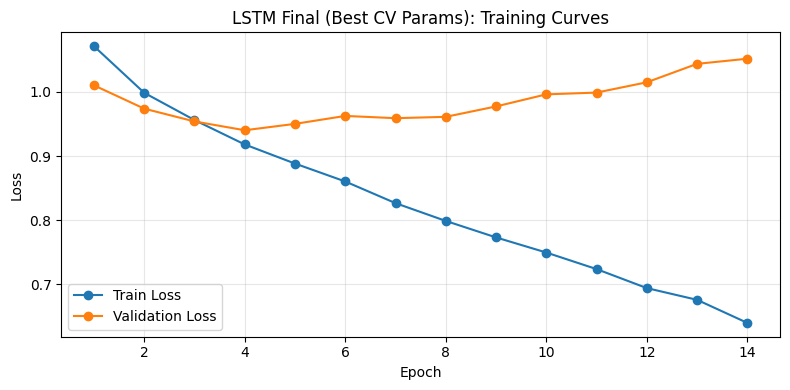


--- LSTM Final (Best CV Params) Performance ---
Train Accuracy: 0.6027
Train Macro-F1: 0.5862
Validation Accuracy: 0.5596
Validation Macro-F1: 0.5456
Test Accuracy: 0.517
Test Macro-F1: 0.4917

Validation Classification Report
                 precision    recall  f1-score   support

  Low (<= 6.80)       0.56      0.74      0.64        39
Mid (6.80-7.25)       0.57      0.39      0.46        33
  High (> 7.25)       0.56      0.51      0.54        37

       accuracy                           0.56       109
      macro avg       0.56      0.55      0.55       109
   weighted avg       0.56      0.56      0.55       109


Test Classification Report
                 precision    recall  f1-score   support

  Low (<= 6.80)       0.50      0.70      0.58        54
Mid (6.80-7.25)       0.39      0.26      0.31        43
  High (> 7.25)       0.63      0.54      0.58        50

       accuracy                           0.52       147
      macro avg       0.51      0.50      0.49       14

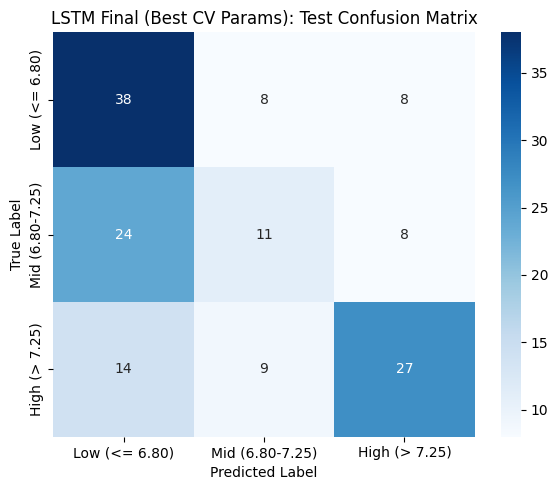


Final training history: {'best_val_loss': 0.9401973485946655, 'best_epoch': 4, 'epochs_ran': 14}
Final training time (seconds): 1.0
Final metrics:
{'train_accuracy': 0.6026731470230863, 'train_macro_f1': 0.5861728899199065, 'val_accuracy': 0.5596330275229358, 'val_macro_f1': 0.5456198730846619, 'test_accuracy': 0.5170068027210885, 'test_macro_f1': 0.4917065669450949}


In [47]:
# CNN+LSTM search/training block is commented out per request.
# best_params = {'conv_channels': 64, 'conv_layers': 2, 'kernel_size': 3, 'lstm_hidden': 64, 'lstm_layers': 2, 'dropout': 0.3, 'lr': 0.001}

# LSTM-only GridSearchCV settings
lstm_cv_param_grid = {
    "lstm_hidden": [16, 32, 64],
    "lstm_layers": [1, 2],
    "dropout": [0.1, 0.2, 0.3],
    "lr": [1e-3, 5e-4],
}

best_cv_params_row, cv_results_df = grid_search_cv_lstm(
    param_grid=lstm_cv_param_grid,
    X=X_train,
    y=y_train,
    n_splits=3,
    batch_size=64,
    cv_epochs=20,
    cv_patience=5,
    random_state=42,
)

print("\nTop LSTM CV results:")
display(cv_results_df.head(10))

if best_cv_params_row is None:
    raise ValueError("LSTM CV search failed to produce results.")

best_params = {
    "lstm_hidden": int(best_cv_params_row["lstm_hidden"]),
    "lstm_layers": int(best_cv_params_row["lstm_layers"]),
    "dropout": float(best_cv_params_row["dropout"]),
    "lr": float(best_cv_params_row["lr"]),
}
print("Best params for LSTM-only:", best_params)

# Final training on train/val split using the selected params
final_model = LSTMClassifier(
    input_size=X_train.shape[2],
    lstm_hidden=best_params["lstm_hidden"],
    lstm_layers=best_params["lstm_layers"],
    dropout=best_params["dropout"],
    n_classes=3,
).to(device)

criterion = nn.CrossEntropyLoss()

start = time.time()
final_model, final_history = train_simple_model(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    lr=best_params["lr"],
    epochs=50,
    patience=10,
    model_name="LSTM Final (Best CV Params)",
)
duration = time.time() - start

final_metrics = report_classification_metrics(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_name="LSTM Final (Best CV Params)",
)

print("\nFinal training history:", final_history)
print("Final training time (seconds):", round(duration, 1))
print("Final metrics:")
print(final_metrics)

TASK 4

In [15]:
# TASK 4

In [4]:
df_regression = pd.read_csv('DL_Dataset.csv')

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
import time


--- LSTM Regression Hyperparameter Search ---
Trial 1 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 1} | val_mse=0.5506 | time=2.3s
Trial 2 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 2} | val_mse=0.4705 | time=2.5s
Trial 3 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 32, 'lstm_layers': 1} | val_mse=0.5164 | time=1.6s
Trial 4 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 32, 'lstm_layers': 2} | val_mse=0.4299 | time=1.8s
Trial 5 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 64, 'lstm_layers': 1} | val_mse=0.4977 | time=1.3s
Trial 6 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 64, 'lstm_layers': 2} | val_mse=0.4187 | time=1.6s
Trial 7 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 128, 'lstm_layers': 1} | val_mse=0.4903 | time=1.2s
Trial 8 | params={'dropout': 0.1, 'lr': 0.001, 'lstm_hidden': 128, 'lstm_layers': 2} | val_mse=0.4272 | time=1.3s
Trial 9 | params={'dropout': 0.1, 'lr': 0.0005,

,dropout,lr,lstm_hidden,lstm_layers,best_epoch,val_mse,time_sec
0,0.2,0.0010,16,2,34,0.412771,2.299110
1,0.3,0.0010,128,2,17,0.417148,1.747416
2,0.2,0.0010,64,2,20,0.418119,1.840836
3,0.1,0.0010,64,2,15,0.418673,1.613139
4,0.3,0.0010,64,2,25,0.419901,2.141321
5,0.2,0.0005,128,2,16,0.422811,1.666713
6,0.3,0.0005,64,2,27,0.423526,2.310487
7,0.3,0.0005,128,2,26,0.424695,2.455286
8,0.1,0.0010,128,2,11,0.427157,1.322931
9,0.1,0.0005,64,2,19,0.427960,1.739602


Best regression params: {'dropout': 0.2, 'lr': 0.001, 'lstm_hidden': 16, 'lstm_layers': 2}

--- Final Training with Best LSTM Regression Params ---
Epoch 01 | Train MSE: 48.4898 | Validation MSE: 42.1083
Epoch 02 | Train MSE: 37.5088 | Validation MSE: 31.9418
Epoch 03 | Train MSE: 27.5954 | Validation MSE: 21.6975
Epoch 04 | Train MSE: 17.1797 | Validation MSE: 11.6097
Epoch 05 | Train MSE: 8.2301 | Validation MSE: 4.1198
Epoch 06 | Train MSE: 2.5968 | Validation MSE: 0.9143
Epoch 07 | Train MSE: 1.1740 | Validation MSE: 0.5804
Epoch 08 | Train MSE: 1.1297 | Validation MSE: 0.5884
Epoch 09 | Train MSE: 1.0039 | Validation MSE: 0.5589
Epoch 10 | Train MSE: 1.0111 | Validation MSE: 0.5648
Epoch 11 | Train MSE: 1.0425 | Validation MSE: 0.5618
Epoch 12 | Train MSE: 0.9849 | Validation MSE: 0.5582
Epoch 13 | Train MSE: 0.9723 | Validation MSE: 0.5530
Epoch 14 | Train MSE: 1.0041 | Validation MSE: 0.5532
Epoch 15 | Train MSE: 1.0318 | Validation MSE: 0.5481
Epoch 16 | Train MSE: 0.9919 | Val

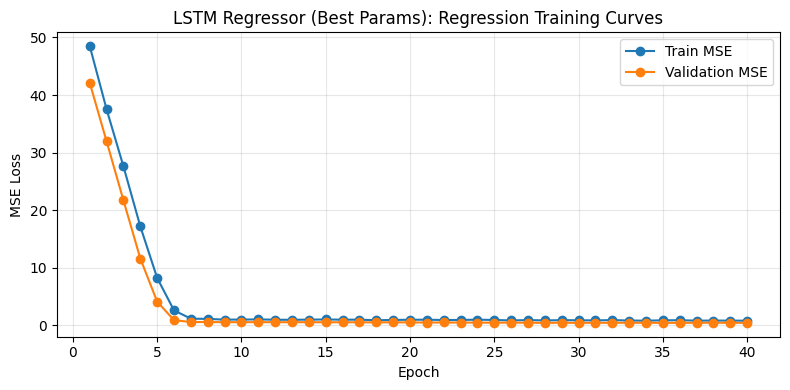

Best epoch (final regression): 30

--- Regression Model Performance ---
Train MSE: 0.4369
Validation MSE: 0.4369
Test MSE: 0.4930


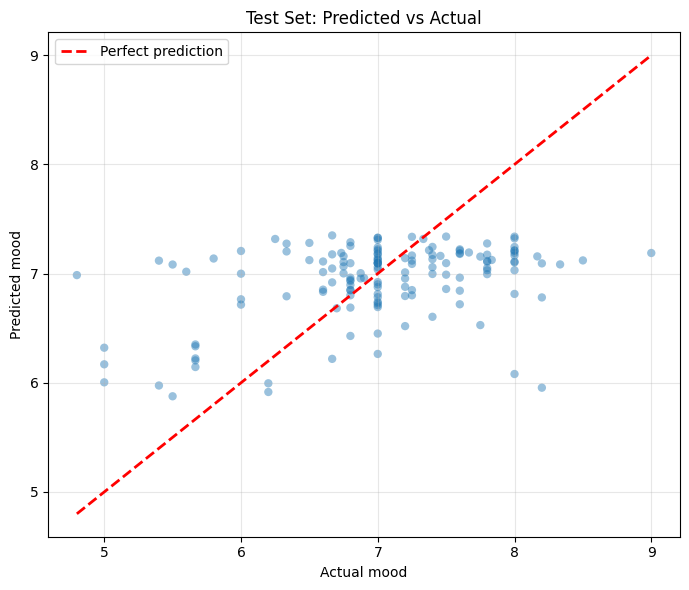

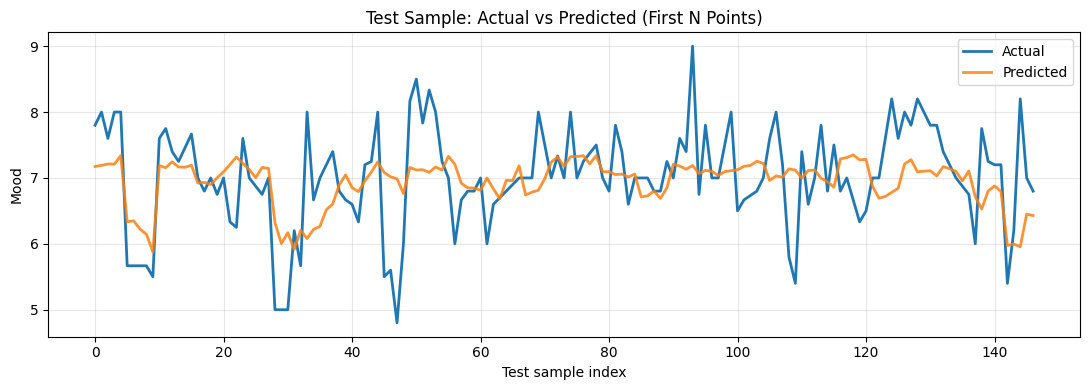

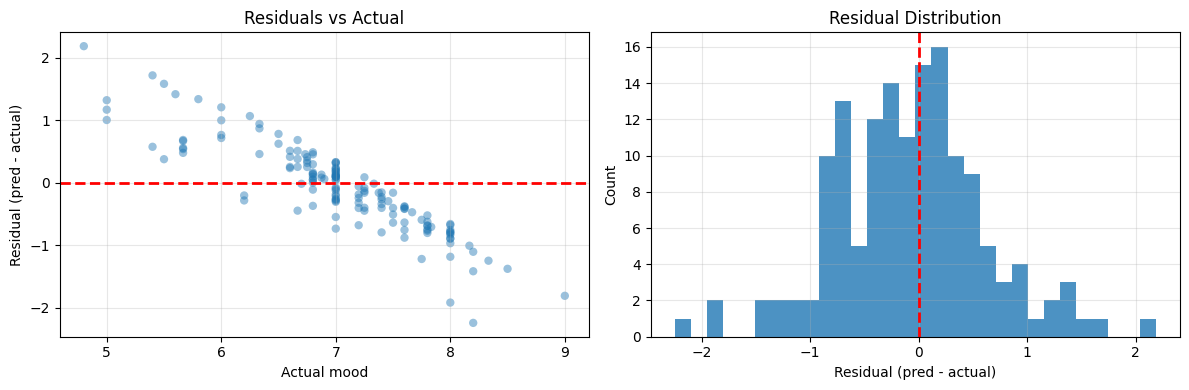


Classification bins not found; using regression-train quantile bins: [-inf, np.float32(6.8), np.float32(7.25), inf]

--- Comparison with Classification Task (Binned Regression) ---
Train Accuracy (from binned regression): 0.4459
Train Macro-F1 (from binned regression): 0.4412
Test Accuracy (from binned regression): 0.3673
Test Macro-F1 (from binned regression): 0.3371

Classification Report (from binned regression)
                 precision    recall  f1-score   support

  Low (<= 6.80)       0.56      0.35      0.43        54
Mid (6.80-7.25)       0.31      0.70      0.43        43
  High (> 7.25)       0.33      0.10      0.15        50

       accuracy                           0.37       147
      macro avg       0.40      0.38      0.34       147
   weighted avg       0.41      0.37      0.34       147



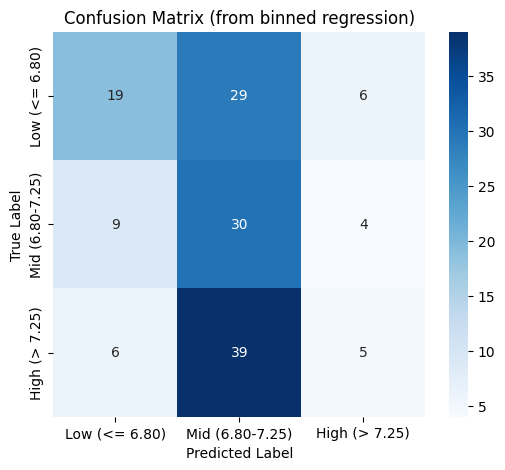

In [26]:
# CNN+LSTM regressor version is commented out per request.
# class CNNLSTMRegressor(nn.Module):
#     def __init__(
#         self,
#         input_size,
#         conv_channels=128,
#         conv_layers=2,
#         kernel_size=3,
#         lstm_hidden=128,
#         lstm_layers=2,
#         dropout=0.3,
#     ):
#         super().__init__()
#         conv_blocks = []
#         in_channels = input_size
#         for _ in range(conv_layers):
#             conv_blocks.extend([
#                 nn.Conv1d(in_channels, conv_channels, kernel_size, padding=kernel_size // 2),
#                 nn.BatchNorm1d(conv_channels),
#                 nn.ReLU(),
#                 nn.Dropout(dropout),
#             ])
#             in_channels = conv_channels
#         self.conv = nn.Sequential(*conv_blocks)

#         lstm_dropout = dropout if lstm_layers > 1 else 0.0
#         self.lstm = nn.LSTM(
#             input_size=conv_channels,
#             hidden_size=lstm_hidden,
#             num_layers=lstm_layers,
#             batch_first=True,
#             dropout=lstm_dropout,
#         )
#         self.norm = nn.LayerNorm(lstm_hidden)
#         self.head = nn.Sequential(
#             nn.Linear(lstm_hidden, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, 1),
#         )

#     def forward(self, x):
#         x = x.permute(0, 2, 1)
#         x = self.conv(x)
#         x = x.permute(0, 2, 1)
#         _, (h_n, _) = self.lstm(x)
#         x = self.norm(h_n[-1])
#         return self.head(x).squeeze(-1)

class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        lstm_hidden=64,
        lstm_layers=2,
        dropout=0.3,
    ):
        super().__init__()
        lstm_dropout = dropout if lstm_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.norm = nn.LayerNorm(lstm_hidden)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        x = self.norm(h_n[-1])
        return self.head(x).squeeze(-1)

# Data Preparation for Regression
df_regression = df_regression.copy()
df_regression[DATE_COL] = pd.to_datetime(df_regression[DATE_COL])
df_regression = df_regression.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

X_train_reg, y_train_reg, X_val_reg, y_val_reg, X_test_reg, y_test_reg = [], [], [], [], [], []

for _, g in df_regression.groupby(ID_COL, sort=False):
    g = g.sort_values(DATE_COL).reset_index(drop=True)
    n = len(g)
    if n <= WINDOW:
        continue

    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)
    train_end = n_train
    val_end = n_train + n_val

    x = g[feature_cols].to_numpy(dtype=np.float32)
    y = g[TARGET_COL].to_numpy(dtype=np.float32)

    for t in range(WINDOW - 1, n - 1):
        seq = x[t - WINDOW + 1:t + 1]
        label = y[t + 1]

        if t + 1 < train_end:
            X_train_reg.append(seq)
            y_train_reg.append(label)
        elif t + 1 < val_end:
            X_val_reg.append(seq)
            y_val_reg.append(label)
        else:
            X_test_reg.append(seq)
            y_test_reg.append(label)

X_train_reg = np.array(X_train_reg, dtype=np.float32)
y_train_reg = np.array(y_train_reg, dtype=np.float32)
X_val_reg = np.array(X_val_reg, dtype=np.float32)
y_val_reg = np.array(y_val_reg, dtype=np.float32)
X_test_reg = np.array(X_test_reg, dtype=np.float32)
y_test_reg = np.array(y_test_reg, dtype=np.float32)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg.reshape(-1, num_features)).reshape(X_train_reg.shape)
X_val_reg = scaler_reg.transform(X_val_reg.reshape(-1, num_features)).reshape(X_val_reg.shape)
X_test_reg = scaler_reg.transform(X_test_reg.reshape(-1, num_features)).reshape(X_test_reg.shape)

train_ds_reg = TensorDataset(torch.tensor(X_train_reg), torch.tensor(y_train_reg))
val_ds_reg = TensorDataset(torch.tensor(X_val_reg), torch.tensor(y_val_reg))
test_ds_reg = TensorDataset(torch.tensor(X_test_reg), torch.tensor(y_test_reg))

train_loader_reg = DataLoader(train_ds_reg, batch_size=64, shuffle=True)
val_loader_reg = DataLoader(val_ds_reg, batch_size=256, shuffle=False)
test_loader_reg = DataLoader(test_ds_reg, batch_size=256, shuffle=False)

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

def train_regression_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    max_epochs=50,
    patience=10,
    verbose=False,
    plot_curves=False,
    model_name="LSTM Regressor",
):
    criterion = nn.MSELoss()
    best_val_mse = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_mse = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_mse += loss.item() * xb.size(0)

        model.eval()
        val_mse = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_mse += criterion(preds, yb).item() * xb.size(0)
        train_mse /= len(train_loader.dataset)
        val_mse /= len(val_loader.dataset)
        train_losses.append(train_mse)
        val_losses.append(val_mse)

        if verbose:
            print(f"Epoch {epoch:02d} | Train MSE: {train_mse:.4f} | Validation MSE: {val_mse:.4f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_mse": train_losses,
        "val_mse": val_losses,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
    }

    if plot_curves and train_losses:
        epochs_ran = len(train_losses)
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, epochs_ran + 1), train_losses, marker="o", label="Train MSE")
        plt.plot(range(1, epochs_ran + 1), val_losses, marker="o", label="Validation MSE")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{model_name}: Regression Training Curves")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return model, best_val_mse, best_epoch, history

def evaluate_regressor(model, loader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb)
            predictions.extend(preds.cpu().numpy())
            actuals.extend(yb.cpu().numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)
    mse = mean_squared_error(actuals, predictions)
    return mse, actuals, predictions

def build_regressor(params):
    return LSTMRegressor(
        input_size=X_train_reg.shape[2],
        lstm_hidden=params["lstm_hidden"],
        lstm_layers=params["lstm_layers"],
        dropout=params["dropout"],
    ).to(device)

def run_regression_grid_search(param_grid, max_epochs=35, patience=8):
    rows = []
    best_params = None
    best_val_mse = float("inf")

    for i, params in enumerate(ParameterGrid(param_grid), start=1):
        model = build_regressor(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

        start = time.time()
        model, _, best_epoch, _ = train_regression_model(
            model=model,
            optimizer=optimizer,
            train_loader=train_loader_reg,
            val_loader=val_loader_reg,
            max_epochs=max_epochs,
            patience=patience,
            verbose=False,
        )
        elapsed = time.time() - start

        val_mse, _, _ = evaluate_regressor(model, val_loader_reg)
        row = {
            **params,
            "best_epoch": best_epoch,
            "val_mse": val_mse,
            "time_sec": elapsed,
        }
        rows.append(row)

        print(f"Trial {i} | params={params} | val_mse={val_mse:.4f} | time={elapsed:.1f}s")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_params = params

    results_df = pd.DataFrame(rows).sort_values("val_mse", ascending=True).reset_index(drop=True)
    return best_params, results_df

# LSTM-only regression hyperparameter search
reg_param_grid = {
    "lstm_hidden": [16, 32, 64, 128],
    "lstm_layers": [1, 2],
    "dropout": [0.1, 0.2, 0.3],
    "lr": [1e-3, 5e-4],
}

print("\n--- LSTM Regression Hyperparameter Search ---")
best_regression_params, regression_results_df = run_regression_grid_search(
    param_grid=reg_param_grid,
    max_epochs=35,
    patience=8,
)

print("\nTop regression trials by val MSE:")
display(regression_results_df.head(10))
print("Best regression params:", best_regression_params)

# Train final regressor with best regression params
final_regressor = build_regressor(best_regression_params)
final_optimizer = torch.optim.Adam(final_regressor.parameters(), lr=best_regression_params["lr"])

print("\n--- Final Training with Best LSTM Regression Params ---")
trained_regressor, _, final_best_epoch, final_regression_history = train_regression_model(
    model=final_regressor,
    optimizer=final_optimizer,
    train_loader=train_loader_reg,
    val_loader=val_loader_reg,
    max_epochs=60,
    patience=10,
    verbose=True,
    plot_curves=True,
    model_name="LSTM Regressor (Best Params)",
)
print(f"Best epoch (final regression): {final_best_epoch}")

# Evaluate regression performance
train_mse, _, _ = evaluate_regressor(trained_regressor, train_loader_reg)
val_mse, _, _ = evaluate_regressor(trained_regressor, val_loader_reg)
test_mse, y_test_true_reg, y_test_pred_reg = evaluate_regressor(trained_regressor, test_loader_reg)

print("\n--- Regression Model Performance ---")
print(f"Train MSE: {train_mse:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

# Predicted-vs-actual and residual diagnostics on test set
residuals_test = y_test_pred_reg - y_test_true_reg
diag_min = float(min(y_test_true_reg.min(), y_test_pred_reg.min()))
diag_max = float(max(y_test_true_reg.max(), y_test_pred_reg.max()))

plt.figure(figsize=(7, 6))
plt.scatter(y_test_true_reg, y_test_pred_reg, alpha=0.45, edgecolor="none")
plt.plot([diag_min, diag_max], [diag_min, diag_max], "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual mood")
plt.ylabel("Predicted mood")
plt.title("Test Set: Predicted vs Actual")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Actual vs predicted over a sample of test points (line plot)
n_plot = min(200, len(y_test_true_reg))
sample_idx = np.arange(n_plot)

plt.figure(figsize=(11, 4))
plt.plot(sample_idx, y_test_true_reg[:n_plot], label="Actual", linewidth=2)
plt.plot(sample_idx, y_test_pred_reg[:n_plot], label="Predicted", linewidth=2, alpha=0.85)
plt.xlabel("Test sample index")
plt.ylabel("Mood")
plt.title("Test Sample: Actual vs Predicted (First N Points)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test_true_reg, residuals_test, alpha=0.45, edgecolor="none")
ax[0].axhline(0, color="red", linestyle="--", linewidth=2)
ax[0].set_xlabel("Actual mood")
ax[0].set_ylabel("Residual (pred - actual)")
ax[0].set_title("Residuals vs Actual")
ax[0].grid(alpha=0.3)

ax[1].hist(residuals_test, bins=30, alpha=0.8)
ax[1].axvline(0, color="red", linestyle="--", linewidth=2)
ax[1].set_xlabel("Residual (pred - actual)")
ax[1].set_ylabel("Count")
ax[1].set_title("Residual Distribution")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Use same bins from classification task for comparison if available
if "bins" in globals() and len(bins) == 4:
    bins_reg = bins
    print("\nUsing classification bins for regression comparison:", bins_reg)
else:
    q33_reg = np.quantile(y_train_reg, 0.33)
    q66_reg = np.quantile(y_train_reg, 0.66)
    bins_reg = [-np.inf, q33_reg, q66_reg, np.inf]
    print("\nClassification bins not found; using regression-train quantile bins:", bins_reg)

labels = [0, 1, 2]
train_mse, y_train_true_reg, y_train_pred_reg = evaluate_regressor(trained_regressor, train_loader_reg)

y_train_pred_binned = np.array(
    pd.cut(y_train_pred_reg, bins=bins_reg, labels=labels, right=True, include_lowest=True),
    dtype=np.int64,
)
y_train_true_binned = np.array(
    pd.cut(y_train_true_reg, bins=bins_reg, labels=labels, right=True, include_lowest=True),
    dtype=np.int64,
)

y_test_pred_binned = np.array(
    pd.cut(y_test_pred_reg, bins=bins_reg, labels=labels, right=True, include_lowest=True),
    dtype=np.int64,
)
y_test_true_binned = np.array(
    pd.cut(y_test_true_reg, bins=bins_reg, labels=labels, right=True, include_lowest=True),
    dtype=np.int64,
)

print("\n--- Comparison with Classification Task (Binned Regression) ---")
train_accuracy = accuracy_score(y_train_true_binned, y_train_pred_binned)
train_macro_f1 = f1_score(y_train_true_binned, y_train_pred_binned, average="macro", zero_division=0)
test_accuracy = accuracy_score(y_test_true_binned, y_test_pred_binned)
test_macro_f1 = f1_score(y_test_true_binned, y_test_pred_binned, average="macro", zero_division=0)
print(f"Train Accuracy (from binned regression): {train_accuracy:.4f}")
print(f"Train Macro-F1 (from binned regression): {train_macro_f1:.4f}")
print(f"Test Accuracy (from binned regression): {test_accuracy:.4f}")
print(f"Test Macro-F1 (from binned regression): {test_macro_f1:.4f}")

if "bins" in globals() and len(bins) == 4:
    class_names = [
        f"Low (<= {bins[1]:.2f})",
        f"Mid ({bins[1]:.2f}-{bins[2]:.2f})",
        f"High (> {bins[2]:.2f})",
    ]
else:
    class_names = [
        f"Low (<= {bins_reg[1]:.2f})",
        f"Mid ({bins_reg[1]:.2f}-{bins_reg[2]:.2f})",
        f"High (> {bins_reg[2]:.2f})",
    ]

print("\nClassification Report (from binned regression)")
print(classification_report(
    y_test_true_binned,
    y_test_pred_binned,
    labels=labels,
    target_names=class_names,
    zero_division=0,
) )

cm = confusion_matrix(y_test_true_binned, y_test_pred_binned, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (from binned regression)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()